## Qiskit -- Problem Set 6. Grover's Algorithm
Cristobal Lillo

In [1]:
import qiskit
from qiskit import *
import qiskit_ibm_runtime
import qiskit_aer

In [2]:
from math import pi

In [10]:
q = QuantumRegister(3)
c = ClassicalRegister(3)
qft = QuantumCircuit(q, c)


qft.barrier()

qft.h(q[0])

# V^2_01

qft.cp(pi/2, q[0], q[1])

# V^3_02
qft.cp(pi/4, q[0], q[2])

qft.barrier()

qft.h(q[1])



qft.cp(pi/2, q[1], q[2])

qft.barrier()

qft.h(q[2])

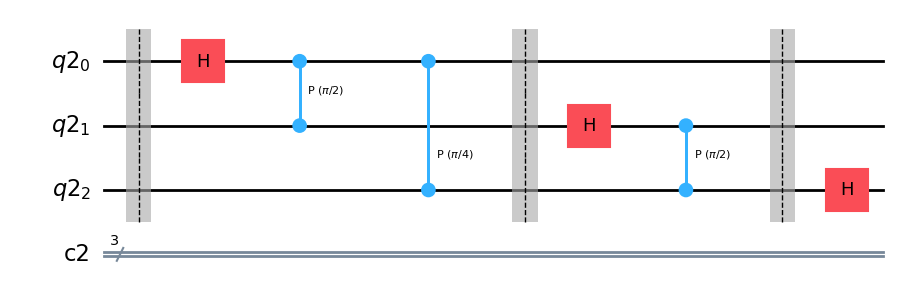

In [11]:
qft.draw(output='mpl')

In [12]:
from qiskit.quantum_info import Statevector
from pprint import pprint

sv = Statevector.from_label("101")
sv_ft = sv.evolve(qft)

pprint(sv_ft.data)

array([ 3.53553391e-01+0.j        , -2.50000000e-01-0.25j      ,
        2.16489014e-17+0.35355339j,  2.50000000e-01-0.25j      ,
       -3.53553391e-01+0.j        ,  2.50000000e-01+0.25j      ,
       -2.16489014e-17-0.35355339j, -2.50000000e-01+0.25j      ])




.353 + 0i

-.25 - 0.25i

0 + 0.353i, 

.25 - 0.25i

-.353 + 0i

.25 + 0.25i

0 - 0.353i

-.25+0.25i


> mathematica FT was 

{

0.353553 + 0. i,

-0.25 - 0.25 I, 

0 + 0.353553 I,

0.25 - 0.25 I, 

-0.353553 + 0. I, 

0.25 + 0.25 I, 

0 - 0.353553 I, 

-0.25 + 0.25 I

}


 Seems to match.

In [18]:
import numpy as np
math_sv = np.array([
    0.353553 + 0.0j,
    -0.25    - 0.25j,
    0.0      + 0.353553j,
    0.25     - 0.25j,
    -0.353553 + 0.0j,
    0.25     + 0.25j,
    0.0      - 0.353553j,
    -0.25    + 0.25j
], dtype=np.complex128)

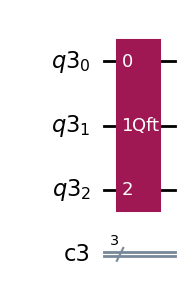

In [13]:
from qiskit.circuit.library import QFTGate

q = QuantumRegister(3)
c = ClassicalRegister(3)
qft2 = QuantumCircuit(q, c)

qft2.append(QFTGate(3), q)

qft2.draw(output='mpl')




In [14]:
sv2 = Statevector.from_label("101")  
sv_ft2 = sv2.evolve(qft2)
print(sv_ft2.data)

[ 3.53553391e-01+0.00000000e+00j -2.50000000e-01-2.50000000e-01j
  1.08244507e-16+3.53553391e-01j  2.50000000e-01-2.50000000e-01j
 -3.53553391e-01+2.16489014e-16j  2.50000000e-01+2.50000000e-01j
 -9.52770505e-16-3.53553391e-01j -2.50000000e-01+2.50000000e-01j]


[ 3.53553391e-01+0.j         -2.50000000e-01-0.25j
  2.16489014e-17+0.35355339j  2.50000000e-01-0.25j
 -3.53553391e-01+0.j          2.50000000e-01+0.25j
 -2.16489014e-17-0.35355339j -2.50000000e-01+0.25j      ]


/Users/CristobalLillo_1/school/phy565/qiskit_2026/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/CristobalLillo_1/school/phy565/qiskit_2026/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


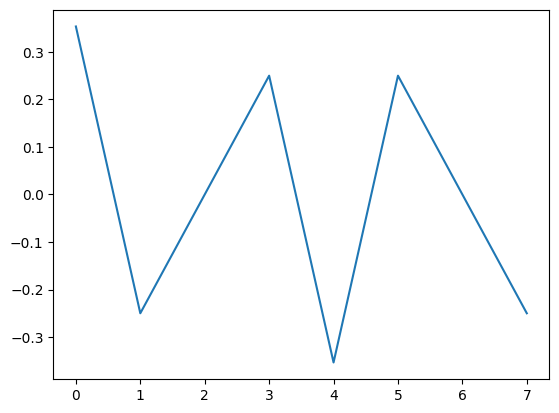

In [16]:
from matplotlib import pyplot as plt

print(sv_ft.data)
plt.plot(sv_ft.data)

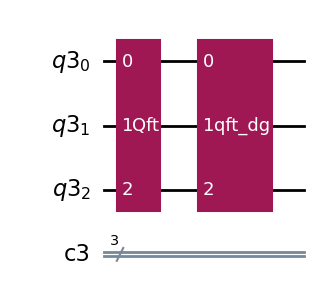

In [20]:

# inverse
qft3 = qft2.copy()
qft3.append(QFTGate(3).inverse(), q)

qft3.draw(output='mpl')

[-2.56951666e-16+1.59807152e-16j  5.55111512e-17-1.22339303e-16j
  2.43073879e-16+1.45929364e-16j -3.88578059e-16+2.83276945e-16j
 -3.40218393e-16-6.72630190e-18j  1.00000000e+00-7.50376287e-16j
  3.54096181e-16+7.15148591e-18j  3.88578059e-16+2.83276945e-16j]


/Users/CristobalLillo_1/school/phy565/qiskit_2026/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/CristobalLillo_1/school/phy565/qiskit_2026/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


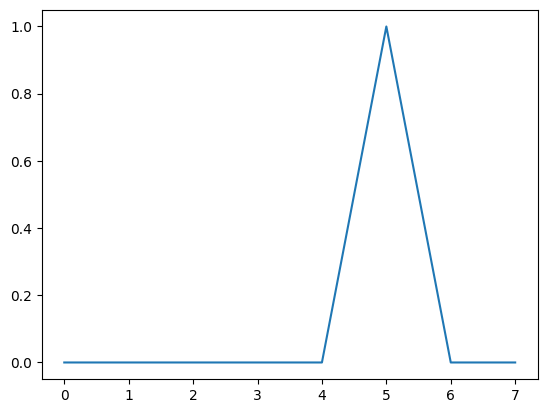

In [22]:
sv3 = Statevector.from_label("101")  
sv_ft3 = sv3.evolve(qft3) # should return 101
print(sv_ft3.data)

import matplotlib.pyplot as plt
plt.plot(sv_ft3.data)

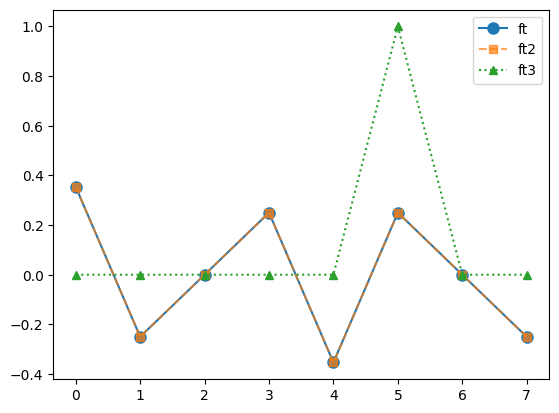

In [26]:
plt.plot(sv_ft.data, 'o-', label='ft', markersize=8)
plt.plot(sv_ft2.data, 's--', label='ft2', markersize=6, alpha=0.7)
plt.plot(sv_ft3.data, '^:', label='ft3')
plt.legend()

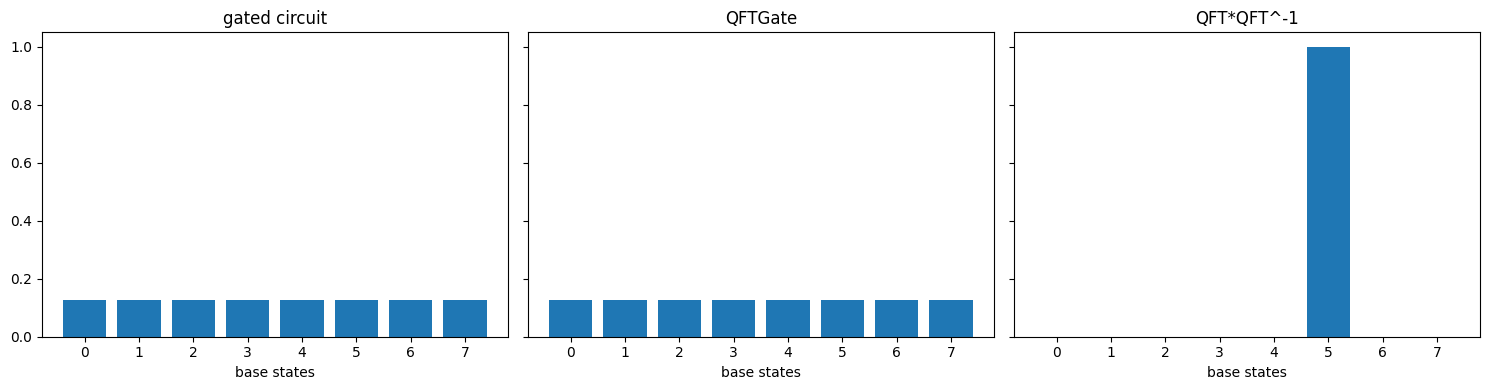

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, data, title in zip(axes, 
    [sv_ft.data, sv_ft2.data, sv_ft3.data], 
    ['gated circuit', 'QFTGate', 'QFT*QFT^-1']):
    ax.bar(range(len(data)), np.abs(data)**2)
    ax.set_title(title)
    ax.set_xlabel('base states')

plt.tight_layout()

> Remarks on QFT: 

QFTGate and the implemented QFT circuit with controlled phase gates give the same superposition of states. 

As expected, QFT and its inverse give back the original state.

---
## 2. Quantum Phase Estimation 

In [11]:
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator

In [12]:
backend = AerSimulator()
sampler = AerSampler()

In [13]:
# Transpile the circuit for the simulator
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
oracle_isa = pm.run(oracle)

In [14]:
job_sim = sampler.run([oracle_isa], shots=4096)
result_sim = job_sim.result()[0] # Get results for the first circuit

In [15]:
# Print the DataBin to see what's inside
list(result_sim.data.keys())

key = list(result_sim.data.keys())[0]
print(key)


x


In [16]:
counts_sim = result_sim.data[key].get_counts()
print(counts_sim)

ancilla_measurments =  result_sim.data["y"].get_counts()
print(ancilla_measurments)

{'000': 4096}
{'0': 4096}


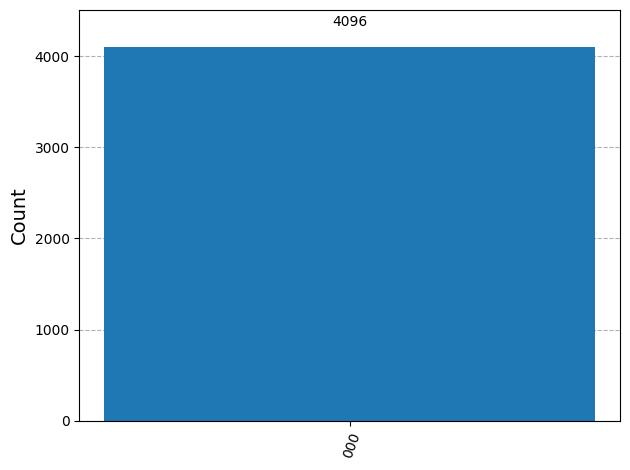

In [17]:
# Plot a histogram of the results
from qiskit.visualization import plot_histogram
plot_histogram(counts_sim)